In [1]:
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
from rich import print

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
# load in dataset
adata = sc.read("/rds/general/user/ztb25/home/PBMC_datasets/integrated_adata.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 880872 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'bbknn', 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'harmony', 'hvg', 'neighbors', 'neighbors_unintegrated', 'pca', 'sample_combined_colors', 'scANVI', 'scanorama', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scANVI', 'X_scVI', 'X_scanorama', 'X_umap', 'X_umap_bbknn', 'X_umap_harmony', 'X_umap_scANVI', 'X_umap_scVI', 'X_umap_scanoram

In [4]:
# Hue = lineage (matches COARSE_COLORS), lightness step = subtype within lineage.
# This makes coarse and fine figures visually consistent, which is worth a lot
# when they sit on facing pages.
FINE_COLORS = {
    # T cells — blue ramp (documented ordinal steps)
    "Tcm/Naive helper T cells":     "#86b6ef",
    "Tem/Effector helper T cells":  "#5598e7",
    "Regulatory T cells":           "#3987e5",
    "Tcm/Naive cytotoxic T cells":  "#2a78d6",
    "Tem/Trm cytotoxic T cells":    "#256abf",
    "Tem/Temra cytotoxic T cells":  "#1c5cab",
    "MAIT cells":                   "#184f95",
    # NK / ILC — orange family
    "NK cells":                     "#eb6834",
    "CD16+ NK cells":               "#b84a20",
    "ILC":                          "#f59b72",
    # B — aqua family
    "Naive B cells":                "#5fcfa2",
    "Memory B cells":               "#1baf7a",
    "Age-associated B cells":       "#127a55",
    "Plasma cells":                 "#eda100",
    # Myeloid — magenta family
    "Classical monocytes":          "#e87ba4",
    "Non-classical monocytes":      "#b8496f",
    "Monocytes":                     "#952c53",
    # DC — green family
    "DC1":                          "#4fb14f",
    "DC2":                          "#008300",
    "pDC":                          "#005a00",
    # other
    "Megakaryocytes/platelets":     "#4a3aa7",
    "HSC/MPP":                      "#e34948",
    "Megakaryocyte precursor":     "#8e7815",
    "ETP":                          "#B3B1B1",
    "ILC3":                          "#61492D",
}


In [5]:
col = "celltypist_cell_label_fine"

# fix category order, then write colours in that same order
# (scanpy matches uns colours to categories by POSITION, so the order must match)
labels = [lab for lab in FINE_COLORS if lab in set(adata.obs[col].astype(str))]
adata.obs[col] = pd.Categorical(adata.obs[col].astype(str), categories=labels, ordered=True)
adata.uns[f"{col}_colors"] = [FINE_COLORS[lab] for lab in labels]

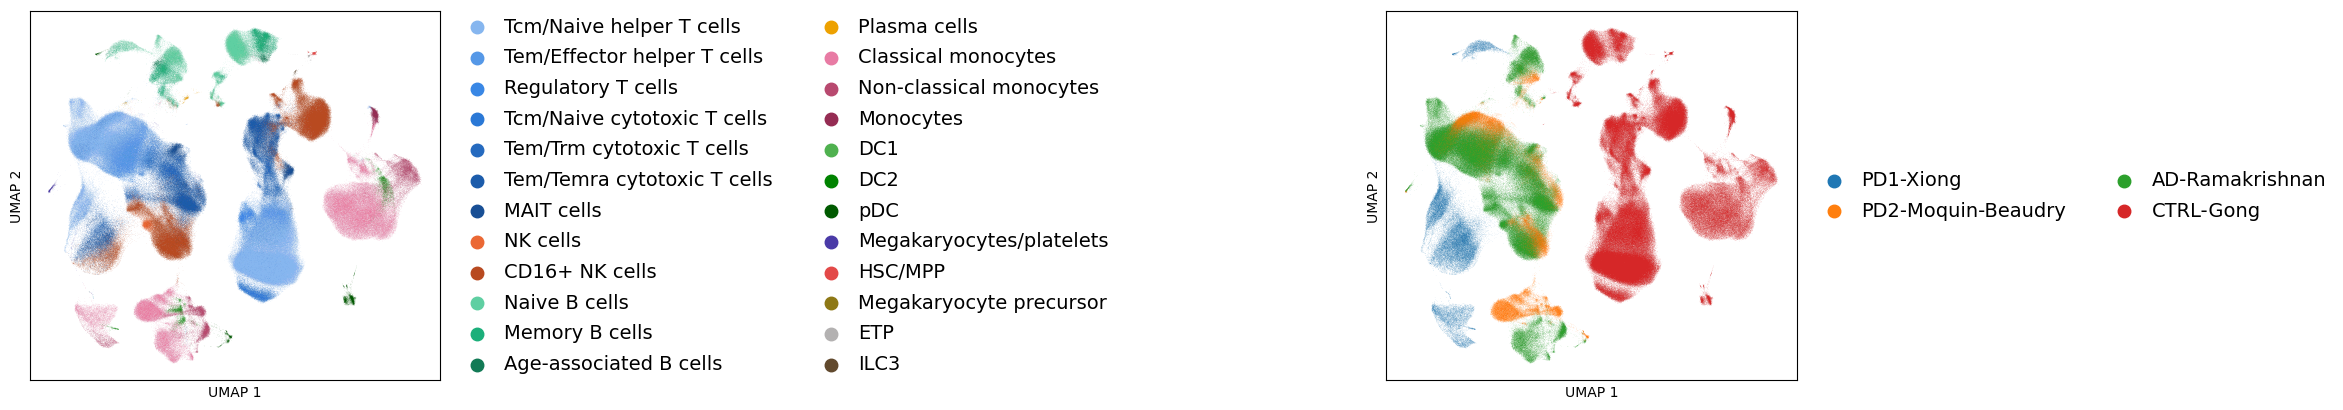

In [7]:
# plot the UMAP (pre integration) coloured by cell type and batch


# # set pallette for the sample colours, using a matplotlib pallette
# adata.uns["sample_combined_colors"] = plt.get_cmap("tab20").colors[: len(adata.uns["sample_combined_colors"])]

# Keep `dataset` as the raw provenance ID; add a display column for figures.
DATASET_LABELS = {"1": "PD1-Xiong", "4": "AD-Ramakrishnan", "5": "PD2-Moquin-Beaudry", "6": "CTRL-Gong"}

adata.obs["dataset_label"] = (
    adata.obs["dataset"].astype(str).map(DATASET_LABELS).astype("category")
)

# order the legend A, B, C, D rather than the mapping's insertion order
adata.obs["dataset_label"] = adata.obs["dataset_label"].cat.reorder_categories(
    ["PD1-Xiong", "PD2-Moquin-Beaudry", "AD-Ramakrishnan", "CTRL-Gong"]
)

axes = sc.pl.embedding(adata, basis = "umap_unintegrated", 
                     color=["celltypist_cell_label_fine", "dataset_label"], wspace=1,
                     title = ["", ""], show = False)
for ax in axes:
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
    handles, labels,
    loc="center left", bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=14,         # text size
    markerscale=1.5,       # dot size
    handletextpad=0.4,
    labelspacing=0.6,
    ncol = 2
)
plt.show()

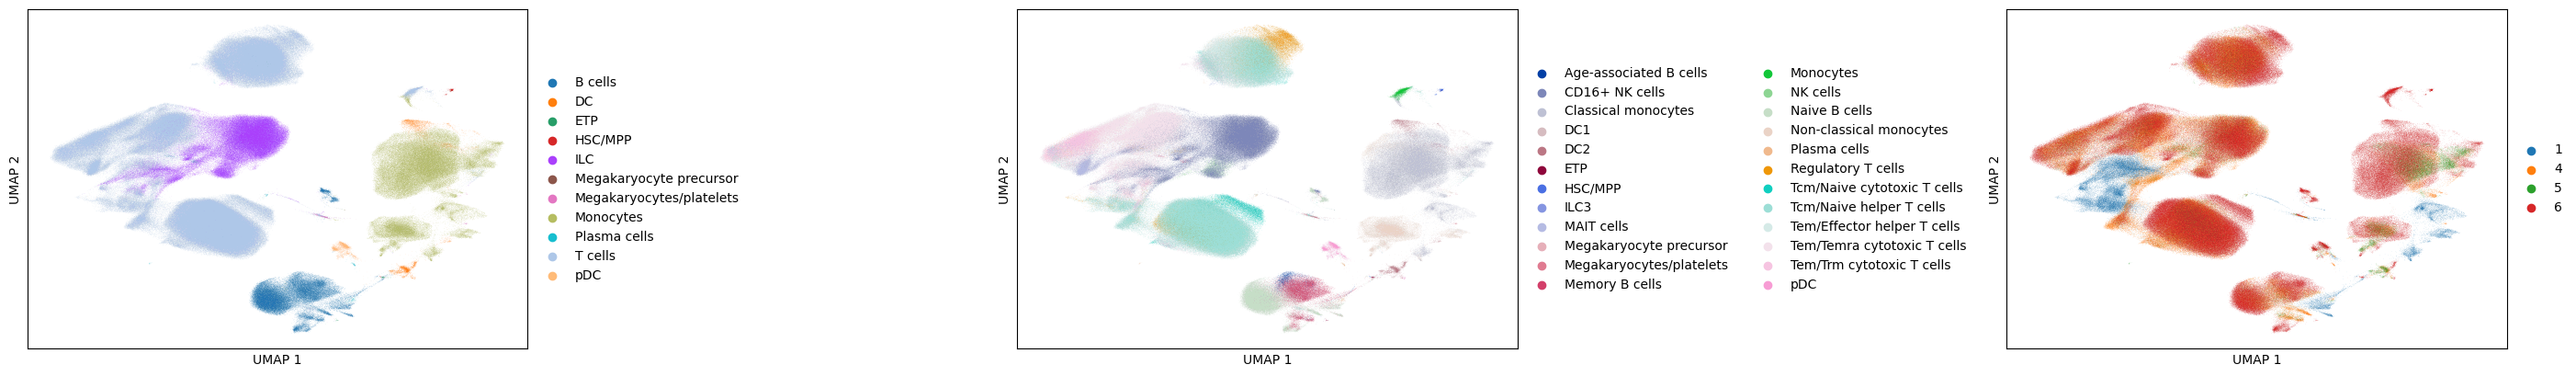

In [14]:
axes = sc.pl.embedding(adata, basis = "umap_harmony", 
                     color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset"], wspace=0.8,
                     title = ["", "", "", ""], show = False)
for ax in axes:
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
plt.show()

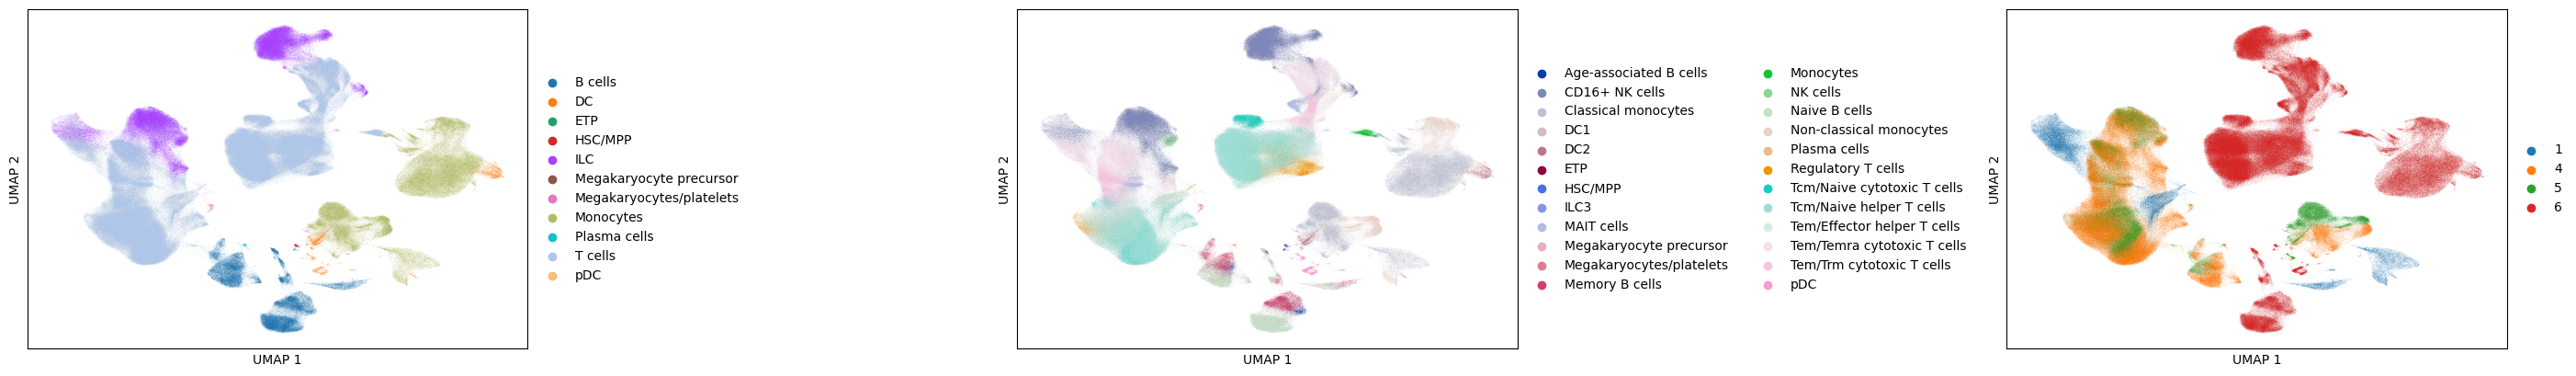

In [15]:
axes = sc.pl.embedding(adata, basis = "umap_bbknn", 
                     color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset"], wspace=0.8,
                     title = ["", "", "", ""], show = False)
for ax in axes:
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
plt.show()

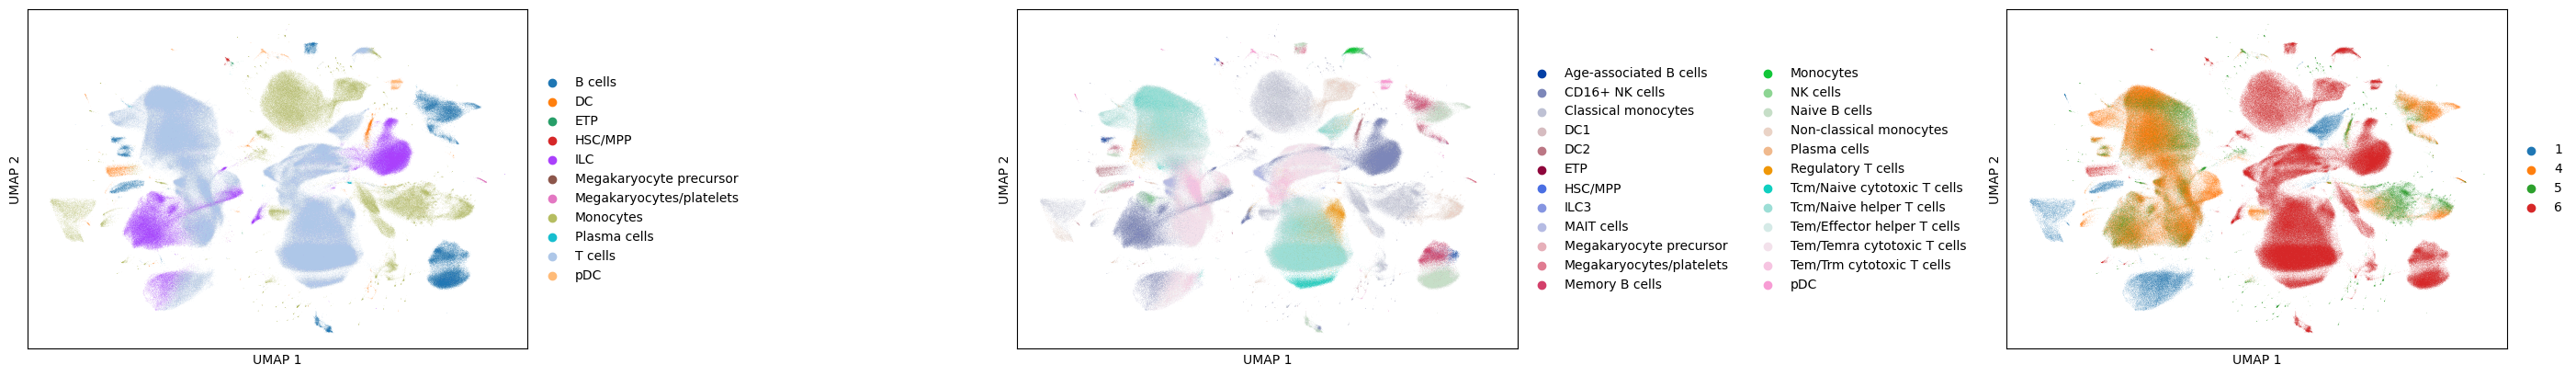

In [16]:
axes = sc.pl.embedding(adata, basis = "umap_scanorama", 
                     color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset"], wspace=0.8,
                     title = ["", "", "", ""], show = False)
for ax in axes:
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
plt.show()

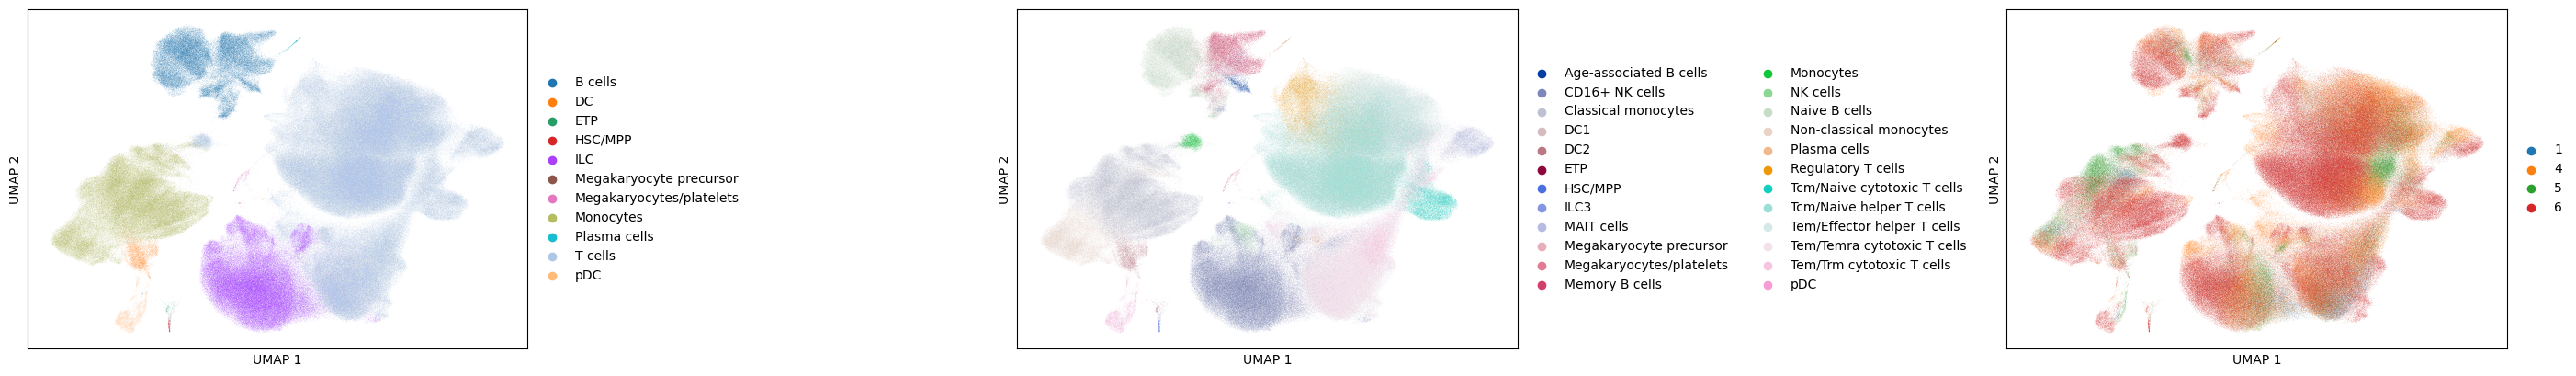

In [17]:
axes = sc.pl.embedding(adata, basis = "umap_scVI", 
                     color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset"], wspace=0.8,
                     title = ["", "", "", ""], show = False)
for ax in axes:
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
plt.show()

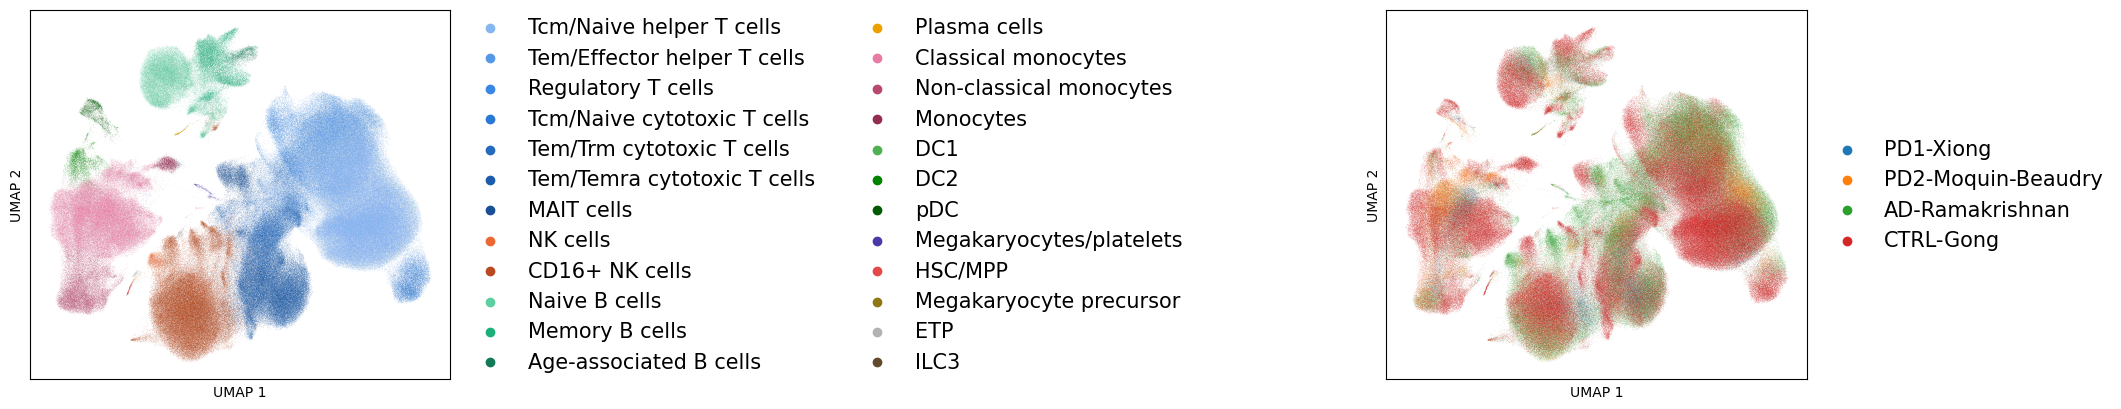

In [8]:
axes = sc.pl.embedding(adata, basis = "umap_scANVI", 
                     color=["celltypist_cell_label_fine", "dataset_label"], wspace=1,
                     title = ["", ""], show = False,
                     legend_fontsize = 15)
for ax in axes:
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_aspect("equal")
plt.show()

In [20]:
adata

AnnData object with n_obs × n_vars = 880872 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'bbknn', 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'harmony', 'hvg', 'neighbors', 'neighbors_unintegrated', 'pca', 'sample_combined_colors', 'scANVI', 'scanorama', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scANVI', 'X_scVI', 'X_scanorama', 'X_umap', 'X_umap_bbknn', 'X_umap_harmony', 'X_umap_scANVI', 'X_umap_scVI', 'X_umap_scanoram

In [21]:
# resave adata with only the best integration (scANVI) for downstream analyses, deleting other embeddings to save space

adata.obsm = {k: v for k, v in adata.obsm.items() if k in ["X_umap_scANVI", "X_umap_unintegrated", "X_scANVI", "X_pca"]}
adata.uns = {k: v for k, v in adata.uns.items() if k in ["celltypist_cell_label_coarse_colors", "celltypist_cell_label_fine_colors", "dataset_colors", "sample_combined_colors", "hvg", "neighbors", "pca", "umap", "scANVI"]}
adata.obsp = {k: v for k, v in adata.obsp.items() if k in ["connectivities", "distances", "connectivities_unintegrated", "distances_unintegrated", "scANVI_connectivities", "scANVI_distances"]}
adata.write("/rds/general/user/ztb25/home/PBMC_datasets/integrated_adata_scANVI.h5ad")

IORegistryError: No method registered for writing <class 'tuple'> into <class 'h5py._hl.group.Group'>

In [ ]:
import numpy as np

# cast any tuple in uns (top level) to an array so h5py can write it
for k, v in adata.uns.items():
    if isinstance(v, tuple):
        adata.uns[k] = np.asarray(v)

adata.write("/rds/general/user/ztb25/home/PBMC_datasets/integrated_adata_scANVI.h5ad")
